# CROQuant Example

---

This notebook provides an example of how to use the CROQuant Algorithm for quantizing a complex rank-one matrix. 
The CROQuant algorithm is designed to find a quantized approximation of a complex rank-one matrix while minimizing the approximation error.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.sparse import csr_matrix
from scipy.sparse.linalg import norm

from lazylinop.butterfly import ksd, ksm, Chain

from src.algos_quantize_rank_one import find_xy_complex, find_xy_rtn_complex
from src.algos_quantize_butterfly import butterfly_quantize_ltr, butterfly_quantize_rtn
from src.fft import get_fft_butterflies

from src.plot_utils import configure_plt


configure_plt(fontsize=16)


np.random.seed(0)  # For reproducibility

/Users/maelchaumette/croquant-code/.venv/lib/python3.12/site-packages/lazylinop/butterfly/GB_factorization.py:17: UserWarning: Did not find einops, therefore use NumPy.
  warn("Did not find einops, therefore use NumPy.")


## Comparison between *CROQuant* and *RTN* algorithms

In [18]:
m = 8
n = 8
t = 3  # Number of bits for quantization

# Generate random complex vectors with uniformly distributed real and imaginary parts
x = np.random.uniform(-1, 1, m) + 1j * np.random.uniform(-1, 1, m)
y = np.random.uniform(-1, 1, n) + 1j * np.random.uniform(-1, 1, n)

In [19]:
# Quantize using CROQuant and RTN algorithms
x_croquant, y_croquant, _, _ = find_xy_complex(x, y, t, delta=2)
x_rtn, y_rtn = find_xy_rtn_complex(x, y, t)

#### Visualization of the error per coordinate

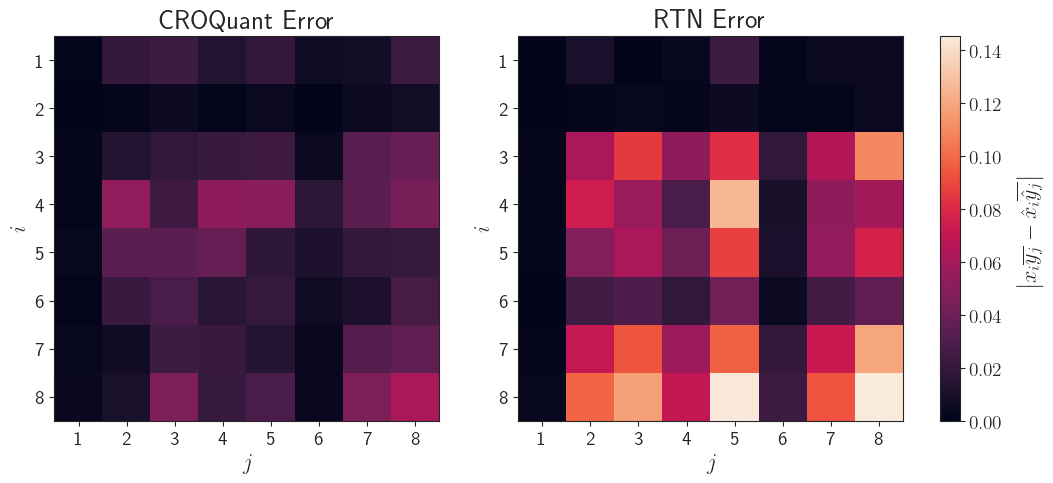

In [20]:
M = np.outer(x, np.conjugate(y))
M_croquant = np.outer(x_croquant, np.conjugate(y_croquant))
M_rtn = np.outer(x_rtn, np.conjugate(y_rtn))

err_croquant = np.abs(M - M_croquant)
err_rtn = np.abs(M - M_rtn)

vmax = max(np.max(err_croquant), np.max(err_rtn))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im1 = axes[0].imshow(err_croquant, vmin=0, vmax=vmax)
axes[0].set_title("CROQuant Error")
axes[0].set_ylabel(r"$i$")
axes[0].set_xlabel(r"$j$")
axes[0].set_xticks(np.arange(n))
axes[0].set_yticks(np.arange(m))
axes[0].set_xticklabels(np.arange(1, n + 1))
axes[0].set_yticklabels(np.arange(1, m + 1))

im2 = axes[1].imshow(err_rtn, vmin=0, vmax=vmax)
axes[1].set_title("RTN Error")
axes[1].set_ylabel(r"$i$")
axes[1].set_xlabel(r"$j$")
axes[1].set_xticks(np.arange(n))
axes[1].set_yticks(np.arange(m))
axes[1].set_xticklabels(np.arange(1, n + 1))
axes[1].set_yticklabels(np.arange(1, m + 1))

cbar = fig.colorbar(im1, ax=axes, fraction=0.046, pad=0.04)
cbar.set_label(r"$\left| x_i \overline{y_j} - \hat{x}_i \overline{\hat{y}_j} \right|$", rotation=90, labelpad=10)

plt.show()

#### Relative quantization error

In [21]:
def rel_error_rk1(x, y, x_hat, y_hat):
    return (
        (np.linalg.norm(x) * np.linalg.norm(y))**2 +
        (np.linalg.norm(x_hat) * np.linalg.norm(y_hat))**2 -
        2 * np.real(np.vdot(x_hat, x) * np.vdot(y, y_hat))
    )

error_croquant = rel_error_rk1(x, y, x_croquant, y_croquant)
error_rtn = rel_error_rk1(x, y, x_rtn, y_rtn)

print(f"CROQuant Relative Error:         {error_croquant:.4e}")
print(f"Round-to-Nearest Relative Error: {error_rtn:.4e}")

CROQuant Relative Error:         3.9875e-02
Round-to-Nearest Relative Error: 2.2608e-01


## Application to Butterfly Factorizations

---

### On random butterfly factorizations

In [22]:
def get_butterfly_factorization(A):
    n = A.shape[0]
    sd_chain = Chain.square_dyadic((n, n))

    lz_butterflies = ksd(A, sd_chain)
    butterflies = []
    for lz_butterfly in lz_butterflies.ks_values:
        butterfly = ksm(lz_butterfly).toarray()
        butterflies.append(csr_matrix(butterfly))

    return butterflies

n = 256
t = 3  # Number of bits for quantization

A = np.random.uniform(-1, 1, (n, n)) + 1j * np.random.uniform(-1, 1, (n, n))
butterflies_A = get_butterfly_factorization(A)

In [23]:
# Quantize the butterfly factorization of A using The Left-to_Right heuristic (using CROQuant) and RTN algorithms
A_ltr = butterfly_quantize_ltr(butterflies_A, t)
A_rtn = butterfly_quantize_rtn(butterflies_A, t)

#### Visualization of the error per coordinate

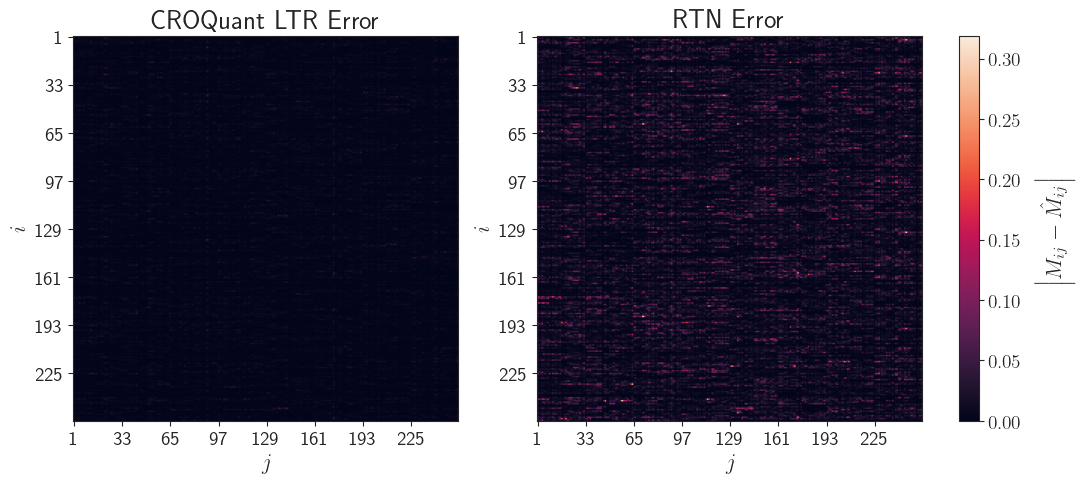

In [25]:
def prod(butterflies):
    result = butterflies[0]
    for butterfly in butterflies[1:]:
        result = result @ butterfly
    return result

M = prod(butterflies_A)
M_ltr = prod(A_ltr)
M_rtn = prod(A_rtn)

err_ltr = np.abs(M - M_ltr).toarray()
err_rtn = np.abs(M - M_rtn).toarray()

vmax = max(np.max(err_ltr), np.max(err_rtn))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
im1 = axes[0].imshow(err_ltr, vmin=0, vmax=vmax)
axes[0].set_title("CROQuant LTR Error")
axes[0].set_ylabel(r"$i$")
axes[0].set_xlabel(r"$j$")
axes[0].set_xticks(np.arange(0, n, n // 8))
axes[0].set_yticks(np.arange(0, n, n // 8))
axes[0].set_xticklabels(np.arange(1, n + 1, n // 8))
axes[0].set_yticklabels(np.arange(1, n + 1, n // 8))

im2 = axes[1].imshow(err_rtn, vmin=0, vmax=vmax)
axes[1].set_title("RTN Error")
axes[1].set_ylabel(r"$i$")
axes[1].set_xlabel(r"$j$")
axes[1].set_xticks(np.arange(0, n, n // 8))
axes[1].set_yticks(np.arange(0, n, n // 8))
axes[1].set_xticklabels(np.arange(1, n + 1, n // 8))
axes[1].set_yticklabels(np.arange(1, n + 1, n // 8))

cbar = fig.colorbar(im1, ax=axes, fraction=0.046, pad=0.04)
cbar.set_label(r"$\left| M_{ij} - \hat{M}_{ij} \right|$", rotation=90, labelpad=10)

plt.show()

#### Relative quantization error

In [9]:
def rel_error_butterfly(butterflies, butterflies_hat):
    result = butterflies[0]
    result_hat = butterflies_hat[0]
    for butterfly, butterfly_hat in zip(butterflies[1:], butterflies_hat[1:]):
        result = result @ butterfly
        result_hat = result_hat @ butterfly_hat

    return norm(result - result_hat) / norm(result_hat)


error_butterfly_ltr = rel_error_butterfly(butterflies_A, A_ltr)
error_butterfly_rtn = rel_error_butterfly(butterflies_A, A_rtn)

print(f"CROQuant Butterfly Relative Error:         {error_butterfly_ltr:.4e}")
print(f"Round-to-Nearest Butterfly Relative Error: {error_butterfly_rtn:.4e}")

CROQuant Butterfly Relative Error:         2.6676e-02
Round-to-Nearest Butterfly Relative Error: 1.4087e-01


### On the Fast Fourier Transform (FFT)

In [10]:
F = get_fft_butterflies(n)
F_ltr = butterfly_quantize_ltr(F, t)
F_rtn = butterfly_quantize_rtn(F, t)

#### Relative quantization error with a random signal

In [11]:
def error_fft_butterfly(butterflies, butterflies_hat, signal):
    result = butterflies[0]
    result_hat = butterflies_hat[0]
    for butterfly, butterfly_hat in zip(butterflies[1:], butterflies_hat[1:]):
        result = result @ butterfly
        result_hat = result_hat @ butterfly_hat

    fft_signal = result @ signal
    fft_signal_hat = result_hat @ signal

    return np.linalg.norm(fft_signal - fft_signal_hat) / np.linalg.norm(fft_signal_hat)


signal = np.random.uniform(-1, 1, n) + 1j * np.random.uniform(-1, 1, n)
error_fft_ltr = error_fft_butterfly(F, F_ltr, signal)
error_fft_rtn = error_fft_butterfly(F, F_rtn, signal)

print(f"CROQuant FFT Relative Error:         {error_fft_ltr:.4e}")
print(f"Round-to-Nearest FFT Relative Error: {error_fft_rtn:.4e}")

CROQuant FFT Relative Error:         1.4983e-02
Round-to-Nearest FFT Relative Error: 6.9456e-02
